In [37]:
import numpy as np
import pandas as pd

# Generating data

y = (x * z)³

In [38]:
x_data = np.random.uniform(low=0, high=1.0, size=(3000,))
#z_data = np.random.standard_normal(size=(3000,))
z_data = np.random.uniform(low=0, high=1.0, size=(3000,))
pow_data = np.power(x_data * z_data, 1)
multi_data = x_data * z_data

df_power = pd.DataFrame(np.array([x_data, z_data, pow_data]).T, columns=['x_data', 'z_data', 'y_data'])
df_multi = pd.DataFrame(np.array([x_data, z_data, multi_data]).T, columns=['x_data', 'z_data', 'y_data'])
df_power

,x_data,z_data,y_data
0,0.304377,0.172919,0.052632
1,0.507867,0.406101,0.206245
2,0.367082,0.846391,0.310695
3,0.435136,0.709811,0.308864
4,0.709826,0.406151,0.288297
...,...,...,...
2995,0.122084,0.099370,0.012131
2996,0.056912,0.679657,0.038680
2997,0.928129,0.887027,0.823276
2998,0.788299,0.905426,0.713746


In [39]:
df_multi

,x_data,z_data,y_data
0,0.304377,0.172919,0.052632
1,0.507867,0.406101,0.206245
2,0.367082,0.846391,0.310695
3,0.435136,0.709811,0.308864
4,0.709826,0.406151,0.288297
...,...,...,...
2995,0.122084,0.099370,0.012131
2996,0.056912,0.679657,0.038680
2997,0.928129,0.887027,0.823276
2998,0.788299,0.905426,0.713746


In [40]:
from spice_net import spice_net_som

spice_net_som.local_min(-4, 4, 0.05, 0.005, lambda x: x ** 2)

8.599438671404554e-06

In [41]:
import spice_net as spn

som_size = 50

som_1 = spn.SpiceNetSom(n_neurons=som_size,
                        value_range_start=-1.0,
                        value_range_end=1.0,
                        lrf_tuning_curve=spn.ConstLRF(0.8),
                        lrf_interaction_kernel=spn.ConstLRF(0.8),
                        make_2d_input=True)
som_2 = spn.SpiceNetSom(n_neurons=som_size,
                        value_range_start=df_power['y_data'].min(),
                        value_range_end=df_power['y_data'].max(),
                        lrf_tuning_curve=spn.ConstLRF(0.8),
                        lrf_interaction_kernel=spn.ConstLRF(0.8))

correlation_matrix = spn.SpiceNetHcm(som_1, som_2, spn.ConstLRF(0.8), spn.ConstLRF(0.8))

spice_net = spn.SpiceNet(correlation_matrix)

In [42]:
input_data = df_power[['x_data', 'z_data']].apply(lambda row: row.to_numpy(), axis=1).tolist()
spice_net.fit(input_data, df_power['y_data'].tolist(), 10, 10, print_output=True)


100%|██████████| 300/300 [00:48<00:00,  6.25it/s]

Time spend on the Components: 
Som: 32.618098735809326 s | Convolution Matrix: 15.19399905204773 s


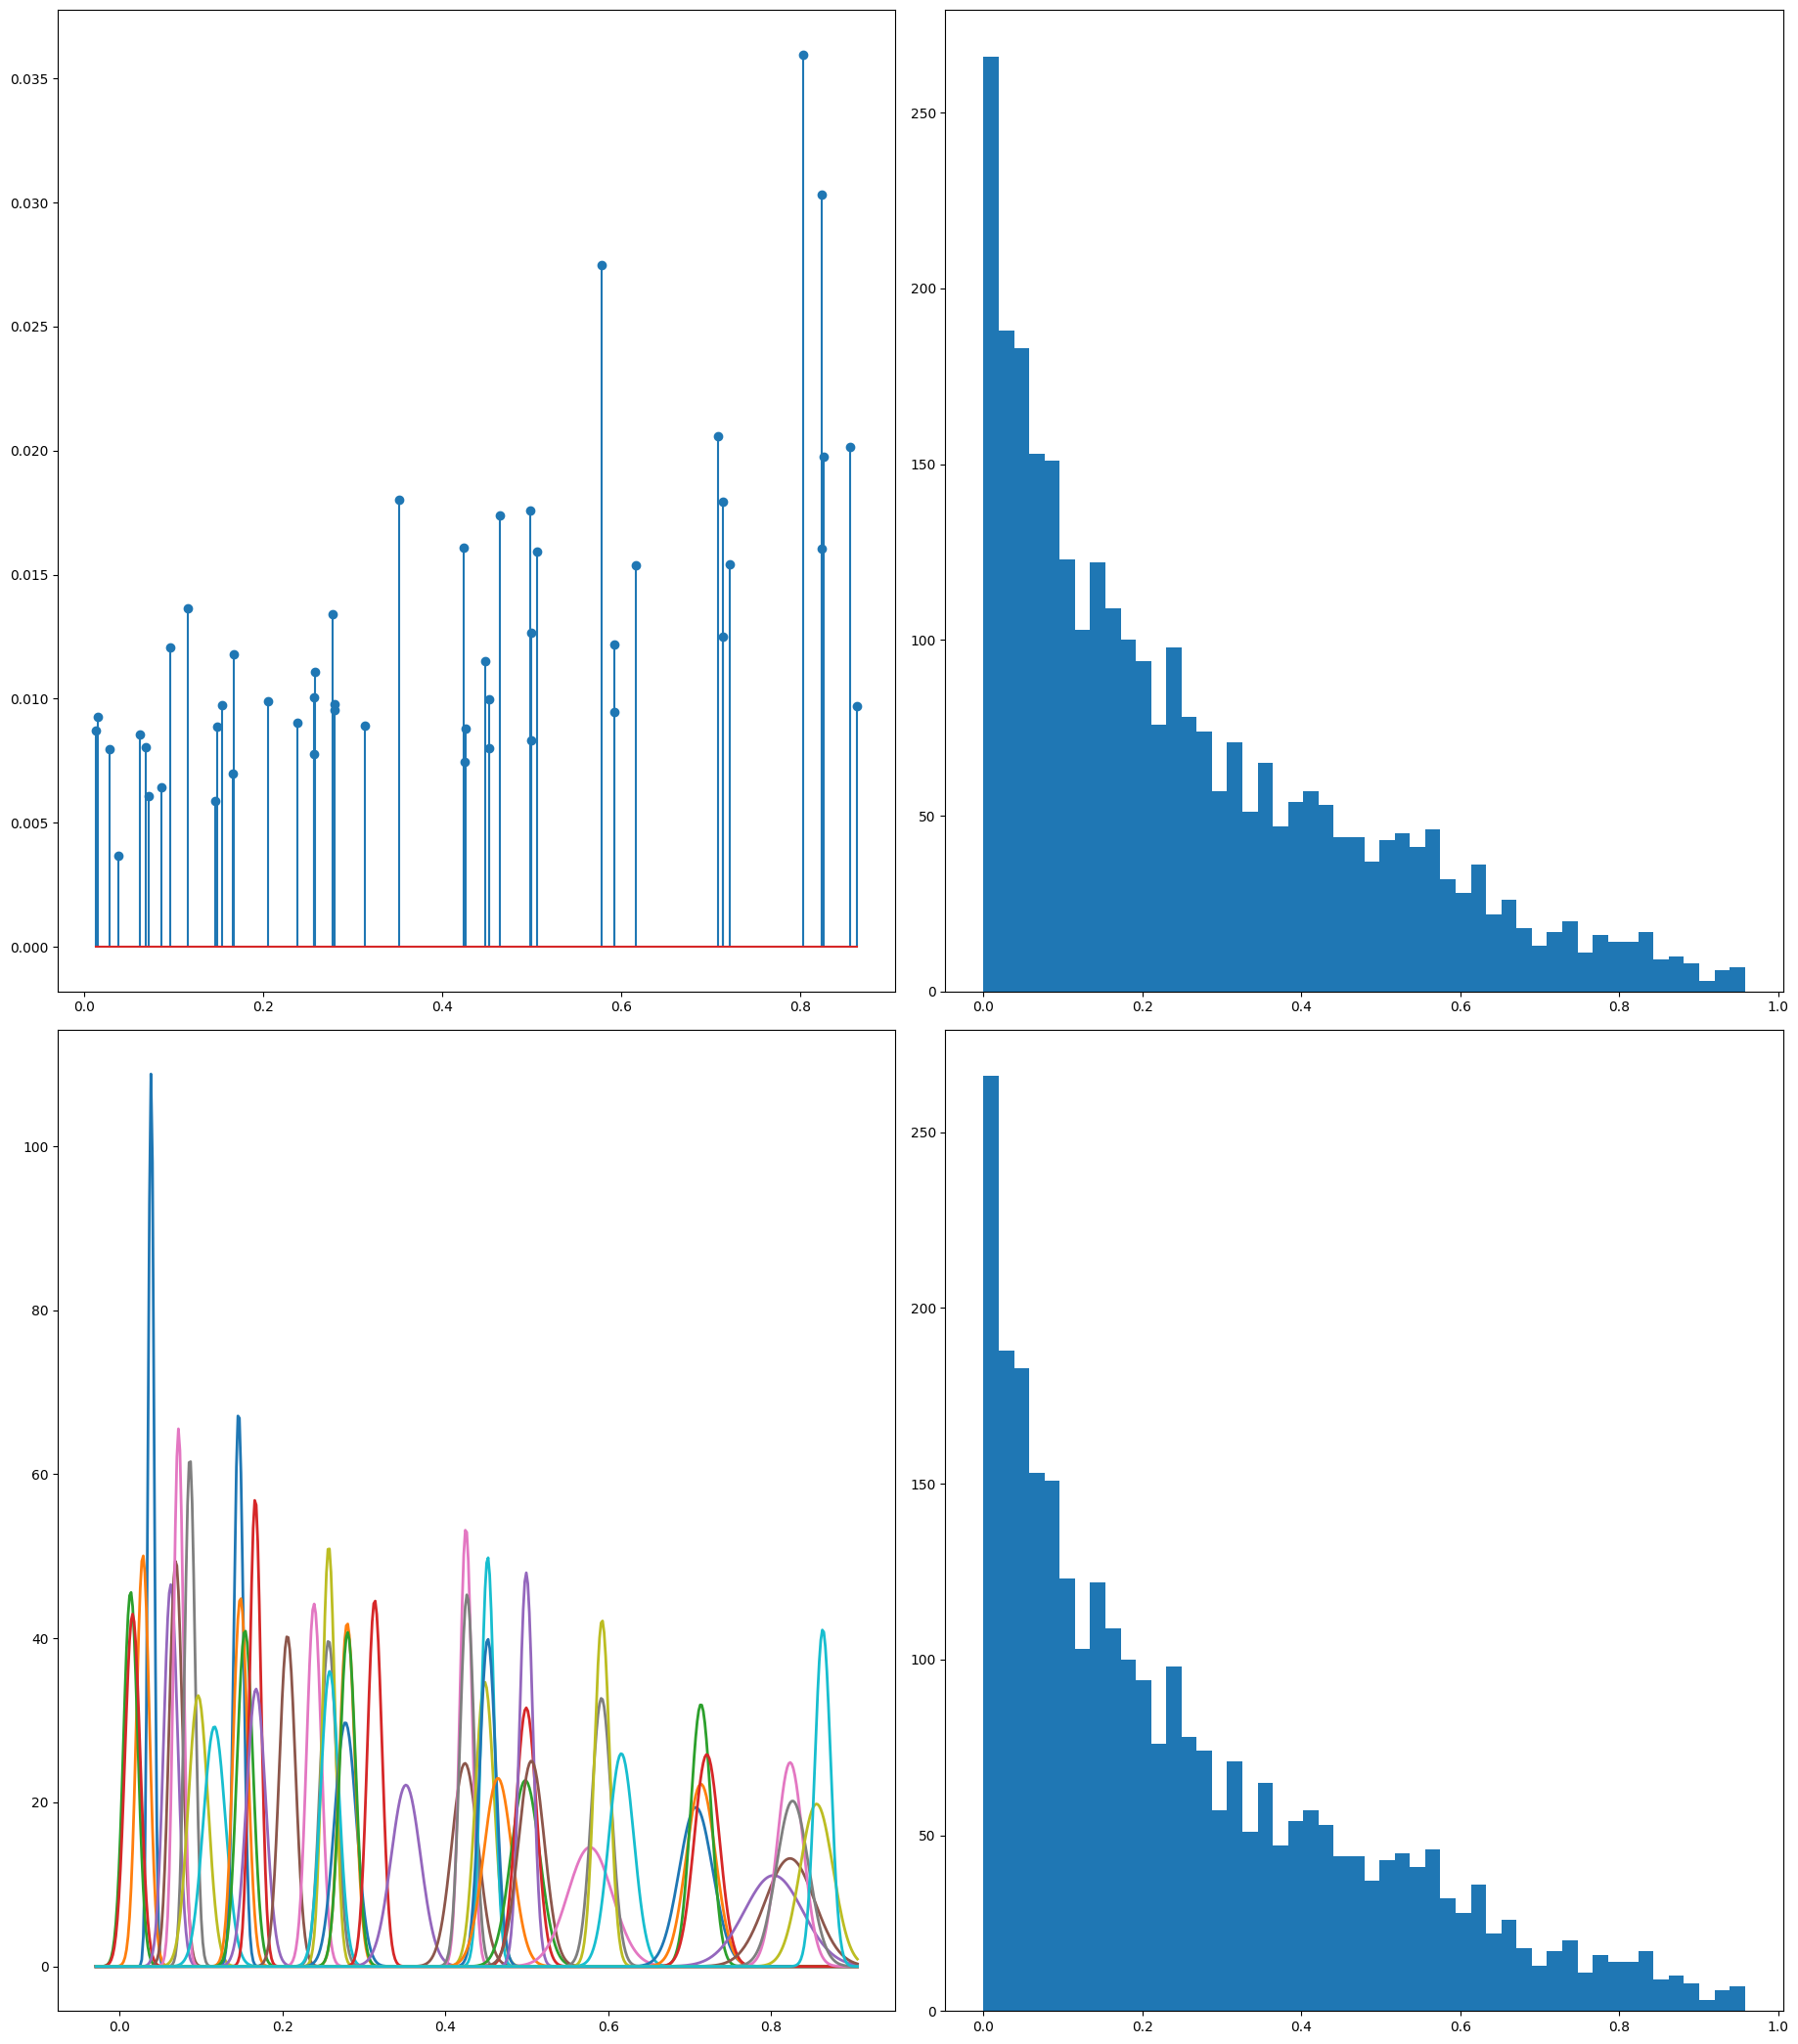

In [45]:
#spn.plot_som(som_1, True)
spn.plot_som(som_2, True)
spn.plot_hcm(correlation_matrix)
spn.plot_hcm(correlation_matrix, True)
spn.plot_som_comparison_to_data(som_2, df_power['y_data'].tolist())

In [44]:
errors = []

for i in range(100):
    test_data = df_power.sample()
    inti_test_value = test_data[['x_data', 'z_data']].iloc[0].to_numpy()
    result_test_value = test_data['y_data'].iloc[0]
    predicted = spice_net.decode(inti_test_value)
    errors.append(abs(predicted - result_test_value) / 2 * 100)
    print(f'Error: {errors[-1]:.6f},\t Predicted: {predicted:.6f},\t Actual: {result_test_value:.6f}')

print(f'Mean Error in % {np.mean(np.array(errors))}')
print(f'Median Error in % {np.median(np.array(errors))}')

7.23666485984347
Error: 3.755812,	 Predicted: 0.243262,	 Actual: 0.168146
9.5868577111819
Error: 0.028983,	 Predicted: 0.135723,	 Actual: 0.136302
20.79842431700607
Error: 4.118408,	 Predicted: 0.148198,	 Actual: 0.065830
2.554842173625367
Error: 16.943726,	 Predicted: 0.458604,	 Actual: 0.119730
0.733078190548421


ValueError: math domain error